**Step 1: Write the C++ Source Code**

In [4]:
%%writefile fractal.cpp
#include <iostream>
#include <fstream>
#include <complex>

int main() {
    // Define image dimensions
    const int width = 800;
    const int height = 800;
    const int max_iterations = 500;

    // Create and open a raw PPM image file
    std::ofstream img("mandelbrot.ppm");
    img << "P3\n" << width << " " << height << "\n255\n";

    std::cout << "C++ Engine: Starting heavy fractal computation..." << std::endl;

    // Loop through every single pixel
    for (int y = 0; y < height; ++y) {
        for (int x = 0; x < width; ++x) {

            // Map pixel coordinates to the complex plane (-2.0 to 1.0, -1.5 to 1.5)
            float pr = -2.0f + (x / (float)width) * 3.0f;
            float pi = -1.5f + (y / (float)height) * 3.0f;

            std::complex<float> c(pr, pi);
            std::complex<float> z(0, 0);

            int iter = 0;
            while (std::abs(z) <= 2.0f && iter < max_iterations) {
                z = z * z + c;
                iter++;
            }

            // Generate an elegant grayscale/blue color mapping based on iteration count
            int r = (iter % 32) * 7;
            int g = (iter % 16) * 14;
            int b = (iter % 8) * 32;

            // Write the RGB pixel data to the file
            img << r << " " << g << " " << b << " ";
        }
    }

    img.close();
    std::cout << "C++ Engine: Computation complete! 'mandelbrot.ppm' saved successfully." << std::endl;
    return 0;
}

Overwriting fractal.cpp


**Step 2: Compile and Run the C++ Engine (Using Bash)**

In [5]:
# 1. Compile the C++ code into an optimized binary executable named 'render_engine'
!g++ -O3 fractal.cpp -o render_engine

# 2. Execute the compiled binary program
!./render_engine

C++ Engine: Starting heavy fractal computation...
C++ Engine: Computation complete! 'mandelbrot.ppm' saved successfully.


**Step 3: Display the Output image**

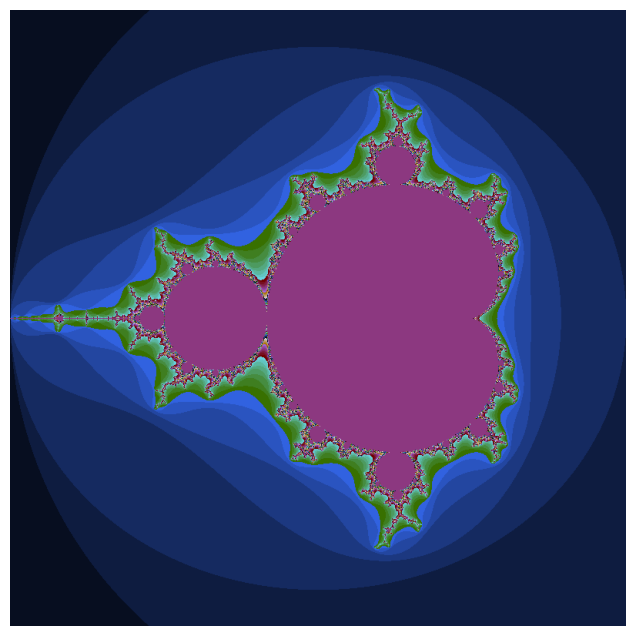

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

# Open the image generated by the C++ binary and show it
img = Image.open("mandelbrot.ppm")
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.show()